# Ejercicio 3: sistema caótico de Rössler

*(Traducción a Python de `ejercicio3.m`, usando `sympy`, `numpy`, `scipy` y `matplotlib`)*

$$\dot x_1 = x_1-x_1x_2-x_3, \qquad \dot x_2 = x_1^2-ax_2, \qquad \dot x_3 = bx_1-cx_3$$

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Puntos singulares (paramétricos)

In [2]:
x1, x2, x3, s, a, b, c = sp.symbols('x1 x2 x3 s a b c', real=True)

f = sp.Matrix([
    x1 - x1*x2 - x3,
    x1**2 - a*x2,
    b*x1 - c*x3
])
f

⎡-x₁⋅x₂ + x₁ - x₃⎤
⎢                ⎥
⎢            2   ⎥
⎢  -a⋅x₂ + x₁    ⎥
⎢                ⎥
⎣  b⋅x₁ - c⋅x₃   ⎦

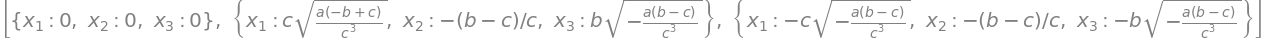

In [3]:
soluciones = sp.solve(f, [x1, x2, x3], dict=True)
soluciones

## Linealización en torno a los puntos singulares (simbólico, con $a,b,c$ genéricos)

In [4]:
J = f.jacobian([x1, x2, x3])
J

⎡1 - x₂  -x₁  -1⎤
⎢               ⎥
⎢ 2⋅x₁   -a   0 ⎥
⎢               ⎥
⎣  b      0   -c⎦

Las expresiones son terribles en general (con $a,b,c$ simbólicos); las mostramos solo por completitud.

In [5]:
for punto in soluciones:
    Je = J.subs(punto)
    autovalores = Je.eigenvals()
    D = (sp.eye(3)*s - Je).det()
    D = sp.collect(D, s)
    # no las imprimimos por su longitud; disponibles en 'autovalores' y 'D'

## Sustituimos valores concretos: $a=0.1,\ b=0.1,\ c=14$

In [6]:
fn = f.subs({a: 0.1, b: 0.1, c: 14})
fn

⎡-x₁⋅x₂ + x₁ - x₃⎤
⎢                ⎥
⎢    2           ⎥
⎢  x₁  - 0.1⋅x₂  ⎥
⎢                ⎥
⎣ 0.1⋅x₁ - 14⋅x₃ ⎦

In [7]:
soluciones_n = sp.solve(fn, [x1, x2, x3], dict=True)
soluciones_n

In [8]:
Jn = fn.jacobian([x1, x2, x3])

autovalores_num = []
for punto in soluciones_n:
    Jen = Jn.subs(punto)
    Jen_num = np.array(Jen.evalf(), dtype=complex)
    lam = np.linalg.eigvals(Jen_num)
    autovalores_num.append(lam)
    print('punto:', {k: complex(v.evalf()) for k, v in punto.items()})
    print('autovalores:', lam)
    print()

punto: {x1: (-0.31509635714446826+0j), x2: (0.9928571428571429+0j), x3: (-0.0022506882653176305+0j)}
autovalores: [ -0.05  +0.4429j  -0.05  -0.4429j -13.9929+0.j    ]

punto: {x1: 0j, x2: 0j, x3: 0j}
autovalores: [  0.9933+0.j -13.9933+0.j  -0.1   +0.j]

punto: {x1: (0.31509635714446826+0j), x2: (0.9928571428571429+0j), x3: (0.0022506882653176305+0j)}
autovalores: [ -0.05  +0.4429j  -0.05  -0.4429j -13.9929+0.j    ]



Convertimos autovalores y puntos a arrays de `numpy` (equivalente a `double(...)` de MATLAB).

In [9]:
x0n = np.array([[complex(punto[x1]).real, complex(punto[x2]).real, complex(punto[x3]).real]
                for punto in soluciones_n])
x0n

array([[-0.3151,  0.9929, -0.0023],
       [ 0.    ,  0.    ,  0.    ],
       [ 0.3151,  0.9929,  0.0023]])

Coincide con los valores del comentario del `.m` original:

```
x0n =
         0         0         0
   -0.3151    0.9929   -0.0023
    0.3151    0.9929    0.0023
```

(el orden de las filas puede variar respecto a MATLAB, ya que `sympy` no garantiza devolver las soluciones en el mismo orden).

## Simulación: acercándonos a un punto inestable

Podemos ahora simular qué pasa si empezamos cerca del punto inestable (el origen) — debería irse a alguno de sus "puntos de equilibrio amigos" (los otros dos, con autovalor real positivo pequeño y un par complejo con parte real ligeramente negativa: inestables en espiral).

In [10]:
def rossler(t, x, a, b, c):
    """Ecuaciones de estado del sistema de Rossler."""
    x1, x2, x3 = x
    return [x1 - x1*x2 - x3, x1**2 - a*x2, b*x1 - c*x3]

In [11]:
param = (0.1, 0.1, 14)

xini1 = [0.01, 0.01, 1]
sol1 = solve_ivp(rossler, [0, 40], xini1, args=param, rtol=1e-9, atol=1e-9, max_step=0.01)

xini2 = [-0.01, -0.01, -1]
sol2 = solve_ivp(rossler, [0, 40], xini2, args=param, rtol=1e-9, atol=1e-9, max_step=0.01)

Representamos los puntos de equilibrio y las dos trayectorias en 3D (equivalente a `plot3`).

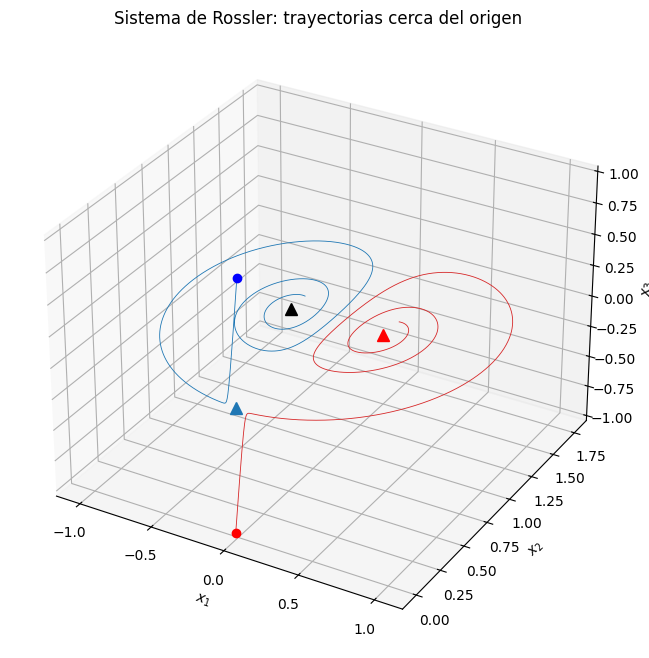

In [12]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')

ax.plot(x0n[0, 0], x0n[0, 1], x0n[0, 2], 'k^', markersize=8)
ax.plot(x0n[1, 0], x0n[1, 1], x0n[1, 2], '^', markersize=8)
ax.plot(x0n[2, 0], x0n[2, 1], x0n[2, 2], 'r^', markersize=8)

ax.plot(sol1.y[0], sol1.y[1], sol1.y[2], color='tab:blue', linewidth=0.6)
ax.plot([xini1[0]], [xini1[1]], [xini1[2]], 'ob')

ax.plot(sol2.y[0], sol2.y[1], sol2.y[2], color='tab:red', linewidth=0.6)
ax.plot([xini2[0]], [xini2[1]], [xini2[2]], 'or')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_title('Sistema de Rossler: trayectorias cerca del origen')
plt.show()

Cada trayectoria, partiendo cerca del origen (inestable), termina orbitando en espiral hacia uno de los otros dos puntos de equilibrio — su respectivo "punto de equilibrio amigo", como bien apunta el comentario del `.m` original. Con $c=14$, el sistema todavía no muestra el atractor caótico clásico de Rössler (para eso, prueba a bajar $c$ a valores en torno a 4-5, un buen experimento adicional para tus estudiantes).